# LangGraph

### StateGraph

In LangGraph (an extension of the LangChain ecosystem), StateGraph is the central builder class used to design stateful, multi-actor applications with LLMs. It allows you to model agent workflows as graphs where nodes represent actions (like calling an LLM or running a tool), and edges dictate the execution path.

StateGraph
- Node
- Edge
- State


In [6]:
import os
from typing import TypedDict
from urllib import response
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=os.getenv("KODEKEY_API_KEY"),
    base_url=os.getenv("KODEKEY_API_URL"),
    model="deepseek/deepseek-v4-flash"
)

In [7]:
# State
class QAState(TypedDict):
    question: str
    answer: str

# Node
def answer_question(state: QAState) -> dict:
    # `llm` should be an object you configure that returns a string for a given prompt.
    response = llm.invoke(state["question"])
    # Return only the keys that this node updates.
    return {"answer": response}

# Edge and Graph
graph = StateGraph(QAState)
graph.add_node("qa", answer_question)
graph.set_entry_point("qa")
graph.set_finish_point("qa")
app = graph.compile()

result = app.invoke({"question": "What is the capital of France?"})
print(result)
# Example output:
# {'question': 'What is the capital of France?', 'answer': 'Paris'}

{'question': 'What is the capital of France?', 'answer': AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 37, 'total_tokens': 62, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 16, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'cost': 2.055e-05}, 'model_provider': 'openai', 'model_name': 'deepseek/deepseek-v4-flash', 'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669', 'id': 'rqsty-cmpl-aecba482-6511-442f-938c-298f708963fc', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0dc49-3493-7092-88f0-67cb7b612c75-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 25, 'total_tokens': 62, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 16}

#### Graph Display

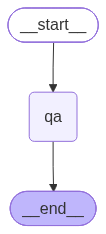

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Conditional Graph

In [11]:
import random
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# 1. Define the state
class State(TypedDict):
    number: int
    message: str

# 2. Define the nodes
def generate_number(state: State) -> State:
    # Generates a random number between 1 and 10
    num = random.randint(1, 10)
    print(f"Generated number: {num}")
    return {"number": num}

def handle_even(state: State) -> State:
    print("The number is even!")
    return {"message": "Even path taken"}

def handle_odd(state: State) -> State:
    print("The number is odd!")
    return {"message": "Odd path taken"}

# 3. Define the routing (conditional) function
def decide_path(state: State) -> Literal["even_node", "odd_node"]:
    if state["number"] % 2 == 0:
        return "even_node"
    return "odd_node"


In [12]:
# 4. Build the graph
builder = StateGraph(State)

# Add nodes
builder.add_node("generator", generate_number)
builder.add_node("even_node", handle_even)
builder.add_node("odd_node", handle_odd)

# Set entry point
builder.add_edge(START, "generator")

# Add conditional edges from generator using a mapping dict
builder.add_conditional_edges(
    "generator",
    decide_path,
    {
        "even_node": "even_node",
        "odd_node": "odd_node",
    },
)

# Connect both outcome nodes to END
builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

# Compile the graph
graph = builder.compile()

In [13]:
# 5. Run the graph
result = graph.invoke({"number": 0, "message": ""})
print("Final state:", result)

Generated number: 6
The number is even!
Final state: {'number': 6, 'message': 'Even path taken'}


# State Management and Iterative Loops

### GraphState

- GraphState
    - Input
    - Intent
    - Result
    - Responce
    - History / Memory

In [2]:
from typing import List, Dict, Any
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import BaseMessage

class GraphState(TypedDict, total=False):
    # required at the start of a run
    input: str

    # optional fields populated as the graph executes
    intent: NotRequired[str]
    chat_history: NotRequired[List[BaseMessage]]
    tool_results: NotRequired[Dict[str, Any]]
    final_response: NotRequired[str]
    loop_count: NotRequired[int]

## State accumulation in LangGraph: reducer

it is the process where node updates are combined with previous state values using specific rules called reducers, rather than simply overwriting existing data.

In LangGraph, a reducer is a function that defines how state updates from nodes are combined with the existing state, rather than simply overwriting it.

LangGraph uses the reducer after each node runs to decide what actually becomes part of the global state.

### 1. List reducer — collect results

This is much more useful for Agentic AI.

In [5]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    results: Annotated[list[str], operator.add]

def search_agent(state: State):
    print("Search agent running...")
    return {
        "results": [
            "Spark 4.0 was released"
        ]
    }

def database_agent(state: State):
    print("Database agent running...")
    return {
        "results": [
            "Database contains Spark job metrics"
        ]
    }

def api_agent(state: State):
    print("API agent running...")
    return {
        "results": [
            "Cluster has 4 workers"
        ]
    }

def summarize(state: State):
    print("\nAll results:")
    for result in state["results"]:
        print("-", result)
    return {}


builder = StateGraph(State)

builder.add_node("search", search_agent)
builder.add_node("database", database_agent)
builder.add_node("api", api_agent)
builder.add_node("summarize", summarize)

builder.add_edge(START, "search")
builder.add_edge("search", "database")
builder.add_edge("database", "api")
builder.add_edge("api", "summarize")
builder.add_edge("summarize", END)

graph = builder.compile()

result = graph.invoke({
    "results": []
})

print("\nFinal State:")
print(result)

Search agent running...
Database agent running...
API agent running...

All results:
- Spark 4.0 was released
- Database contains Spark job metrics
- Cluster has 4 workers

Final State:
{'results': ['Spark 4.0 was released', 'Database contains Spark job metrics', 'Cluster has 4 workers']}


### 2. Custom reducer

Now let's create our own reducer.
Suppose multiple agents return scores and we want to keep the highest score.

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

def merge_dicts(old, new):
    return {
        **old,
        **new
    }

class State(TypedDict):
    metrics: Annotated[dict, merge_dicts]

def spark_agent(state):
    return {
        "metrics": {
            "spark_jobs": 120
        }
    }

def presto_agent(state):
    return {
        "metrics": {
            "presto_queries": 450
        }
    }

def kubernetes_agent(state):
    return {
        "metrics": {
            "pods": 35
        }
    }

builder = StateGraph(State)

builder.add_node("spark", spark_agent)
builder.add_node("presto", presto_agent)
builder.add_node("kubernetes", kubernetes_agent)

builder.add_edge(START, "spark")
builder.add_edge("spark", "presto")
builder.add_edge("presto", "kubernetes")
builder.add_edge("kubernetes", END)

graph = builder.compile()

result = graph.invoke({
    "metrics": {}
})

print(result)

{'metrics': {'spark_jobs': 120, 'presto_queries': 450, 'pods': 35}}


## Handling Multiple State Schemas langgraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# -------------------------
# Input schema
# -------------------------
class InputState(TypedDict):
    question: str

# -------------------------
# Internal schema
# -------------------------
class OverallState(TypedDict):
    question: str
    search_result: str
    analysis: str

# -------------------------
# Output schema
# -------------------------
class OutputState(TypedDict):
    answer: str

# -------------------------
# Node 1
# -------------------------
def search(state: InputState):
    print("Question:", state["question"])
    return {
        "search_result": "Spark job failed because executor memory was insufficient."
    }

# -------------------------
# Node 2
# -------------------------
def analyze(state: OverallState):
    result = state["search_result"]
    analysis = f"Analysis based on search: {result}"
    return {
        "analysis": analysis
    }

# -------------------------
# Node 3
# -------------------------
def generate_answer(state: OverallState):
    return {
        "answer": state["analysis"]
    }

# -------------------------
# Build graph
# -------------------------
builder = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState
)

builder.add_node("search", search)
builder.add_node("analyze", analyze)
builder.add_node("answer", generate_answer)

builder.add_edge(START, "search")
builder.add_edge("search", "analyze")
builder.add_edge("analyze", "answer")
builder.add_edge("answer", END)
graph = builder.compile()

# -------------------------
# Invoke
# -------------------------
result = graph.invoke({
    "question": "Why is my Spark job failing?"
})
print(result)

Question: Why is my Spark job failing?
{'answer': 'Analysis based on search: Spark job failed because executor memory was insufficient.'}


# Long-Term Memory and Stateful Persistence

## Stateful Persistence Checkpoints

LangGraph enables agents to persist runtime state so workflows can pause and resume without losing progress. This capability is critical for real-world automation that spans hours or days, depends on external systems, or requires user input across multiple sessions.

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

# Define the state
class State(TypedDict):
    message: str
    steps: list[str]

# Define simple nodes
def start_node(state: State):
    return {"message": "Hello", "steps": ["start"]}

def middle_node(state: State):
    return {"message": state["message"] + " -> Middle", "steps": state["steps"] + ["middle"]}

def end_node(state: State):
    return {"message": state["message"] + " -> End", "steps": state["steps"] + ["end"]}

LangGraph InMemorySaver checkpointer saves a checkpoint at every super-step, which generally means after each node execution.

- start_node → checkpoint 1
- middle_node → checkpoint 2
- end_node → checkpoint 3

In [3]:
# Create the workflow
workflow = StateGraph(State)
workflow.add_node(start_node)
workflow.add_node(middle_node)
workflow.add_node(end_node)

workflow.add_edge(START, "start_node")
workflow.add_edge("start_node", "middle_node")
workflow.add_edge("middle_node", "end_node")
workflow.add_edge("end_node", END)

In [10]:
# Set up checkpointing
checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

# Run the graph
config={"configurable": {"thread_id": "1"}}
graph.invoke({"message": "", "steps": []}, config)

# Access checkpoint data
print(checkpointer.get(config))

{'v': 4, 'ts': '2026-09-27T13:23:47.267814+00:00', 'id': '1f1ba76a-b939-6188-8003-c32344cbe31d', 'channel_versions': {'__start__': '00000000000000000000000000000002.0.8978963799580337', 'message': '00000000000000000000000000000005.0.8041184742783933', 'steps': '00000000000000000000000000000005.0.8041184742783933', 'branch:to:start_node': '00000000000000000000000000000003.0.47062796956438535', 'branch:to:middle_node': '00000000000000000000000000000004.0.82987304817492', 'branch:to:end_node': '00000000000000000000000000000005.0.8041184742783933'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000001.0.8716602562173438'}, 'start_node': {'branch:to:start_node': '00000000000000000000000000000002.0.8978963799580337'}, 'middle_node': {'branch:to:middle_node': '00000000000000000000000000000003.0.47062796956438535'}, 'end_node': {'branch:to:end_node': '00000000000000000000000000000004.0.82987304817492'}}, 'updated_channels': ['message', 'steps'], 'chan

**How to retrieving and inspecting state?**

◉ Current State
Access the latest state of any thread instantly by calling graph.get_state(config).

In [15]:
config = {"configurable": {"thread_id": "workflow_123"}}
current_state = graph.get_state(config)

print(f"Current values: {current_state.values}")
print(f"Next nodes: {current_state.next}")
print(f"Step: {current_state.metadata}")

Current values: {}
Next nodes: ()
Step: None


In [16]:
history = list(graph.get_state_history(config))

# History is ordered from most recent to oldest
for i, checkpoint in enumerate(history):
    print(f"Step {i}: {checkpoint.values}")
    print(f"Next: {checkpoint.next}")
    print("---")

### Managing Concurrency and State Isolation per User Session

In production you typically serve hundreds or thousands of users with a single LangGraph application. Each user session must be isolated so one user’s data, progress, or memory never leaks into another’s flow .

Concurrency management means safely running many graph executions in parallel: chatbot sessions, workflows, or event-triggered runs. Each graph run must keep its own runtime state, memory, and execution history. LangGraph exposes isolated runtime state, but your application must wire up session tracking, persistence, and identifiers correctly.

In [26]:
# python
# Step 1: Define state schema
from typing import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph import StateGraph, START, END
import uuid

class GraphState(TypedDict):
    messages: list[str]

# Step 2: Generate a unique session ID
session_id = str(uuid.uuid4())

# Step 3: Build and compile the graph
builder = StateGraph(GraphState)
builder.add_edge(START, END)

# builder.add_node(...), add edges, etc.
graph_app = builder.compile()

# Step 4: Pass session ID as thread_id for isolation
config = {"configurable": {"thread_id": session_id}}

# Step 5: Run graph with session-specific execution
graph_app.invoke({"messages": []}, config=config)

{'messages': []}

## Leveraging the LangGraph Store

In [25]:
from typing import TypedDict
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END

class AppState(TypedDict):
    messages: list[str]

# -------------------------
# Node
# -------------------------
def chat_node(state: AppState):
    print("Current state:", state)
    return {
        "messages": state["messages"] + [
            "Assistant: I received your message."
        ]
    }

# -------------------------
# Build graph
# -------------------------
builder = StateGraph(AppState)

builder.add_node("chat", chat_node)

# START → chat → END
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# -------------------------
# Checkpointer
# -------------------------
with SqliteSaver.from_conn_string("graph.db") as checkpointer:
    app = builder.compile(
        checkpointer=checkpointer
    )

    config = {
        "configurable": {
            "thread_id": "user_456"
        }
    }

    # First invocation
    result = app.invoke(
        {
            "messages": ["Hi!, I am Ajay"]
        },
        config=config
    )

    print("First:")
    print(result)

    # Second invocation
    result = app.invoke(
        {
            "messages": ["Continue our conversation, and what is my name?"]
        },
        config=config
    )

    print("Second:")
    print(result)

Current state: {'messages': ['Hi!, I am Ajay']}
First:
{'messages': ['Hi!, I am Ajay', 'Assistant: I received your message.']}
Current state: {'messages': ['Continue our conversation, and what is my name?']}
Second:
{'messages': ['Continue our conversation, and what is my name?', 'Assistant: I received your message.']}


# Human-in-the-Loop (HILT) Architectures

Human-in-the-Loop (HITL) in LangGraph means pausing an agent workflow and asking a human to review, approve, reject, or modify something before the graph continues.

It is especially useful for agentic AI workflows where an LLM may perform actions such as calling APIs, modifying data, deploying code, or executing tools.

### Interrupt and FeedBack

In [38]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command


# ---------------------------------------------------------
# 1. Define graph state
# ---------------------------------------------------------

class AgentState(TypedDict):
    user_request: str
    proposed_action: str
    approved: bool
    result: str


# ---------------------------------------------------------
# 2. Analyze user request
# ---------------------------------------------------------

def analyze_request(state: AgentState):

    print("\n[Agent] Analyzing request...")

    request = state["user_request"]

    # In a real application this would be an LLM.
    # Here we keep it deterministic for learning HITL.

    if "restart" in request.lower():
        action = "Restart the Presto worker pod presto-worker-123"

    else:
        action = "No supported action identified"

    print(f"[Agent] Proposed action: {action}")

    return {
        "proposed_action": action
    }


# ---------------------------------------------------------
# 3. Human approval
# ---------------------------------------------------------

def human_approval(state: AgentState):

    print("\n[Agent] Waiting for human approval...")

    decision = interrupt({
        "type": "approval",
        "message": "Do you approve this operation?",
        "action": state["proposed_action"]
    })

    print(f"[Human decision] {decision}")

    return {
        "approved": decision
    }


# ---------------------------------------------------------
# 4. Decide what to do after human response
# ---------------------------------------------------------

def route_after_approval(state: AgentState):

    if state["approved"]:
        return "execute"

    return "reject"


# ---------------------------------------------------------
# 5. Execute approved operation
# ---------------------------------------------------------

def execute_action(state: AgentState):

    action = state["proposed_action"]

    print("\n[Agent] Executing action...")
    print(f"[Agent] {action}")

    # In a real application:
    #
    # subprocess.run([
    #     "kubectl",
    #     "delete",
    #     "pod",
    #     "presto-worker-123",
    #     "-n",
    #     "ezpresto"
    # ])

    result = f"Successfully executed: {action}"

    return {
        "result": result
    }


# ---------------------------------------------------------
# 6. Handle rejection
# ---------------------------------------------------------

def reject_action(state: AgentState):

    print("\n[Agent] Human rejected the operation.")

    return {
        "result": "Operation rejected by human."
    }


# ---------------------------------------------------------
# 7. Build graph
# ---------------------------------------------------------

builder = StateGraph(AgentState)

builder.add_node(
    "analyze",
    analyze_request
)

builder.add_node(
    "human_approval",
    human_approval
)

builder.add_node(
    "execute",
    execute_action
)

builder.add_node(
    "reject",
    reject_action
)


# ---------------------------------------------------------
# 8. Define graph flow
# ---------------------------------------------------------

builder.add_edge(
    START,
    "analyze"
)

builder.add_edge(
    "analyze",
    "human_approval"
)

builder.add_conditional_edges(
    "human_approval",
    route_after_approval,
    {
        "execute": "execute",
        "reject": "reject"
    }
)

builder.add_edge(
    "execute",
    END
)

builder.add_edge(
    "reject",
    END
)


# ---------------------------------------------------------
# 9. Add checkpointer
# ---------------------------------------------------------

checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer
)


# ---------------------------------------------------------
# 10. Create thread
# ---------------------------------------------------------

config = {
    "configurable": {
        "thread_id": "k8s-operation-001"
    }
}


# ---------------------------------------------------------
# 11. Start graph
# ---------------------------------------------------------

print("\nStarting agent...\n")

result = graph.invoke(
    {
        "user_request": "Restart the Presto worker",
        "proposed_action": "",
        "approved": False,
        "result": ""
    },
    config=config
)


print("\nGraph paused for human approval.")
print("Interrupt information:")
print(result)


# ---------------------------------------------------------
# 12. Resume after human approval
# ---------------------------------------------------------

print("\nResuming graph with human approval...\n")

result = graph.invoke(
    Command(resume=True),
    config=config
)


print("\nFinal result:")
print(result)


Starting agent...


[Agent] Analyzing request...
[Agent] Proposed action: Restart the Presto worker pod presto-worker-123

[Agent] Waiting for human approval...

Graph paused for human approval.
Interrupt information:
{'user_request': 'Restart the Presto worker', 'proposed_action': 'Restart the Presto worker pod presto-worker-123', 'approved': False, 'result': '', '__interrupt__': [Interrupt(value={'type': 'approval', 'message': 'Do you approve this operation?', 'action': 'Restart the Presto worker pod presto-worker-123'}, id='c726d91e8fd6ca20193215ad995f8385')]}

Resuming graph with human approval...


[Agent] Waiting for human approval...
[Human decision] True

[Agent] Executing action...
[Agent] Restart the Presto worker pod presto-worker-123

Final result:
{'user_request': 'Restart the Presto worker', 'proposed_action': 'Restart the Presto worker pod presto-worker-123', 'approved': True, 'result': 'Successfully executed: Restart the Presto worker pod presto-worker-123'}


# Advanced Control and Debugging UX

### Enabling State Editing Mid Execution

There are two common approaches to pause a graph in LangGraph:
- Conditional edge: add a condition that evaluates to a paused state and triggers an external intervention.
- Custom pause node: create a node whose sole responsibility is to halt execution and surface the current state to an external system.


In [39]:
from langgraph.types import interrupt

def editable_pause_node(state):
    # Pause execution and expose the current state to an external system
    updated_state = interrupt({
        "message": "Edit the state if needed before continuing",
        "state_snapshot": state
    })

    # Resume execution with the updated state
    return updated_state

### Implementing Dynamic Breakpoints Based on Conditions

A dynamic breakpoint is a conditional inspection point embedded in graph logic. It evaluates values in the execution state—for example, confidence, tool_name, or a retry_count. When the condition is true, the graph issues an interrupt and pauses so the current state can be inspected, modified, or logged. When the condition is false, execution proceeds uninterrupted. This yields context-aware pauses that reduce noise and focus developer attention where it’s needed.

In [40]:
from langgraph.types import interrupt

def confidence_breakpoint(state):
    """
    Pause execution if the confidence in `state` is too low.
    Returns the (possibly unchanged) state so the graph can continue.
    """
    confidence = state.get("confidence", 1.0)

    # Pause execution if confidence is too low
    if confidence < 0.7:
        interrupt({
            "message": "Low confidence detected",
            "confidence": confidence,
            "state_snapshot": state
        })

    return state